# Taller: busqueda local en el 8-puzzle

**Introduccion a la Inteligencia Artificial, Universidad Sergio Arboleda**

Integrantes: Mario Jimenez, Juan David Andrade y Camilo Diaz.

Comparacion de ascenso de colinas (steepest, estocastico y con
reinicios por perturbacion) y temple simulado sobre 30 tableros
resolubles del 8-puzzle. La teoria completa esta en
`informe/informe.tex`; este notebook reporta los resultados.

## Nota de reproducibilidad

Este notebook **no recalcula** los experimentos: solo carga los CSV de
`resultados/datos/` y las figuras de `resultados/figuras/`. Por eso
abre y corre en segundos.

Los resultados completos se generan desde la raiz del repositorio con:

```
python src/experimentos.py
```

- Con los barridos congelados (`RECALCULAR_BARRIDOS = False`, el valor
  por defecto) tarda unos pocos minutos: corre la tabla principal y
  lee los barridos de T0/alpha y de K desde los CSV.
- Con `RECALCULAR_BARRIDOS = True` recalcula tambien los barridos
  completos (unos 50 minutos). Solo hace falta si cambia algo
  estructural: `T_MINIMO`, `ITERACIONES_POR_TEMPERATURA`, tableros,
  semillas o grillas.

Todo lo aleatorio se repite con 10 semillas por tablero (30 tableros x
10 semillas = 300 corridas por configuracion). Steepest es
determinista y corre una vez por tablero.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Code, Image, display

RAIZ = Path.cwd()
if RAIZ.name == "notebook":
    RAIZ = RAIZ.parent
DATOS = RAIZ / "resultados" / "datos"
FIGURAS = RAIZ / "resultados" / "figuras"
FUENTES = RAIZ / "src"

pd.set_option("display.precision", 2)
pd.set_option("display.max_colwidth", 120)


def mostrar_codigo(modulo):
    """Muestra el codigo fuente del modulo sin ejecutarlo."""
    display(Code(filename=str(FUENTES / f"{modulo}.py"),
                 language="python"))


def mostrar_figura(nombre):
    display(Image(filename=str(FIGURAS / f"{nombre}.png")))


# Verificacion de rutas: el notebook debe encontrar las tres carpetas
# relativas a la raiz del proyecto (la carpeta que contiene notebook/).
print("Raiz del proyecto:", RAIZ.name)
for carpeta, patron in [(FUENTES, "*.py"), (DATOS, "*.csv"),
                        (FIGURAS, "*.png")]:
    cantidad = len(list(carpeta.glob(patron)))
    estado = "OK" if cantidad else "NO ENCONTRADA"
    print(f"  {carpeta.relative_to(RAIZ).as_posix()}/: "
          f"{cantidad} archivos {patron} ({estado})")

Raiz del proyecto: Taller_Colina-Temple
  src/: 7 archivos *.py (OK)
  resultados/datos/: 7 archivos *.csv (OK)
  resultados/figuras/: 16 archivos *.png (OK)


## 1. Codigo fuente (referencia, no se ejecuta)

Las celdas siguientes solo muestran el codigo de `src/` para dejar
constancia de como se genero todo.

### `src/formulacion.py`

Estado, vecindad, h(s) = distancia Manhattan, resolubilidad y conjunto de pruebas.

In [2]:
mostrar_codigo("formulacion")

"""Formulacion del 8-puzzle como problema de busqueda local."""

import numpy as np

META = (1, 2, 3, 4, 5, 6, 7, 8, 0)
LADO = 3


def fila_columna(indice):
    """Convierte un indice de la tupla (0-8) en (fila, columna)."""
    return divmod(indice, LADO)


def _posiciones_meta(meta=META):
    """Indice en la tupla meta para cada ficha (incluyendo el 0)."""
    posiciones = [0] * len(meta)
    for indice, ficha in enumerate(meta):
        posiciones[ficha] = indice
    return posiciones


_POSICIONES_META = _posiciones_meta()


def distancia_manhattan(estado, meta=META):
    """Suma de distancias Manhattan de cada ficha a su lugar meta.

    El 0 (casilla vacia) no se cuenta: no es una ficha que deba
    moverse a un lugar especifico. h(s) = 0 unicamente en la meta,
    ya que la distancia Manhattan de una ficha es 0 solo si ya esta
    en su posicion objetivo, y la suma de terminos no negativos es
    0 solo si todos lo son.
    """
    posiciones_meta = (
        _POSICIONES_META if meta is META else _posiciones_meta(meta))
    total = 0
    for indice, ficha in enumerate(estado):
        if ficha == 0:
            continue
        fila_actual, columna_actual = fila_columna(indice)
        fila_meta, columna_meta = fila_columna(posiciones_meta[ficha])
        total += (abs(fila_actual - fila_meta)
                  + abs(columna_actual - columna_meta))
    return total


def vecinos(estado):
    """Estados alcanzables al mover el vacio a una casilla adyacente.

    Cada vecino intercambia la posicion del 0 con una ficha adyacente
    en la cuadricula (arriba, abajo, izquierda o derecha). Ese
    intercambio mueve exactamente una ficha una casilla: la acerca o
    la aleja en 1 de su posicion meta en esa coordenada, y deja el
    resto de las fichas intactas, por lo que h(s) cambia en
    exactamente +1 o -1 respecto al estado actual.
    """
    indice_vacio = estado.index(0)
    fila_vacio, columna_vacio = fila_columna(indice_vacio)
    movimientos = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    resultado = []
    for delta_fila, delta_columna in movimientos:
        fila_nueva = fila_vacio + delta_fila
        columna_nueva = columna_vacio + delta_columna
        if not (0 <= fila_nueva < LADO and 0 <= columna_nueva < LADO):
            continue
        indice_nuevo = fila_nueva * LADO + columna_nueva
        estado_lista = list(estado)
        estado_lista[indice_vacio], estado_lista[indice_nuevo] = (
            estado_lista[indice_nuevo], estado_lista[indice_vacio])
        resultado.append(tuple(estado_lista))
    return resultado


def verificar_delta_h(estado, meta=META):
    """Confirma que cada vecino cambia h(s) en exactamente +-1.

    Se usa como evidencia empirica de la propiedad que sustenta la
    regla de aceptacion del temple simulado (exp(-deltaE/T) con
    deltaE en {-1, +1}).
    """
    h_actual = distancia_manhattan(estado, meta)
    return all(
        abs(distancia_manhattan(vecino, meta) - h_actual) == 1
        for vecino in vecinos(estado)
    )


def contar_inversiones(estado):
    """Cuenta pares fuera de orden entre las fichas, ignorando el 0."""
    fichas = [ficha for ficha in estado if ficha != 0]
    inversiones = 0
    for i in range(len(fichas)):
        for j in range(i + 1, len(fichas)):
            if fichas[i] > fichas[j]:
                inversiones += 1
    return inversiones


def es_resoluble(estado, meta=META):
    """Indica si el estado es alcanzable desde la meta.

    En un tablero de lado impar (3x3) dos permutaciones pertenecen a
    la misma clase de alcanzabilidad si y solo si tienen la misma
    paridad de inversiones. Como la meta tiene 0 inversiones (par),
    un estado es resoluble si su numero de inversiones es par. Solo
    la mitad de las 9! permutaciones cumple esta condicion.
    """
    inversiones_estado = contar_inversiones(estado)
    inversiones_meta = contar_inversiones(meta)
    return inversiones_estado % 2 == inversiones_meta % 2


def generar_tablero_resoluble

### `src/ascenso.py`

Steepest, estocastico y reinicios por perturbacion.

In [3]:
mostrar_codigo("ascenso")

"""Variantes de ascenso de colinas para el 8-puzzle."""

from collections import namedtuple

from formulacion import distancia_manhattan, vecinos

# Largo de la caminata aleatoria con que se perturba el tablero
# asignado en cada reinicio. Del mismo orden de magnitud que la
# perturbacion usada en el notebook exploratorio: suficiente para
# salir de la cuenca del optimo local, pero partiendo siempre del
# tablero asignado.
MOVIMIENTOS_PERTURBACION = 20

ResultadoAscenso = namedtuple(
    "ResultadoAscenso",
    ["estado_final", "h_final", "evaluaciones", "movimientos"])

ResultadoReinicios = namedtuple(
    "ResultadoReinicios",
    ["estado_final", "h_final", "evaluaciones", "h_iniciales",
     "estado_partida", "cantidad_intentos", "longitud_solucion"])


def steepest(tablero_inicial):
    """Ascenso de colinas mas pronunciado.

    En cada paso evalua todos los vecinos y se mueve al mejor de
    ellos. Se detiene cuando ningun vecino mejora el h actual (optimo
    local o la meta).
    """
    estado_actual = tablero_inicial
    h_actual = distancia_manhattan(estado_actual)
    evaluaciones = 1
    movimientos = 0
    while True:
        candidatos = vecinos(estado_actual)
        valores_h = [distancia_manhattan(v) for v in candidatos]
        evaluaciones += len(candidatos)
        mejor_h = min(valores_h)
        if mejor_h >= h_actual:
            break
        mejor_vecino = candidatos[valores_h.index(mejor_h)]
        estado_actual, h_actual = mejor_vecino, mejor_h
        movimientos += 1
    return ResultadoAscenso(
        estado_actual, h_actual, evaluaciones, movimientos)


def estocastico(tablero_inicial, generador):
    """Ascenso de colinas estocastico.

    En cada paso evalua todos los vecinos, pero en vez de moverse
    siempre al mejor, elige al azar entre los que mejoran el h
    actual. Se detiene cuando ninguno mejora.
    """
    estado_actual = tablero_inicial
    h_actual = distancia_manhattan(estado_actual)
    evaluaciones = 1
    movimientos = 0
    while True:
        candidatos = vecinos(estado_actual)
        valores_h = [distancia_manhattan(v) for v in candidatos]
        evaluaciones += len(candidatos)
        mejores = [(v, h) for v, h in zip(candidatos, valores_h)
                   if h < h_actual]
        if not mejores:
            break
        indice = generador.integers(0, len(mejores))
        estado_actual, h_actual = mejores[indice]
        movimientos += 1
    return ResultadoAscenso(
        estado_actual, h_actual, evaluaciones, movimientos)


def caminata_aleatoria(tablero, cantidad_movimientos, generador):
    """Aplica `cantidad_movimientos` movimientos legales elegidos al
    azar (uniforme entre los vecinos) a partir de `tablero`."""
    estado = tablero
    for _ in range(cantidad_movimientos):
        candidatos = vecinos(estado)
        estado = candidatos[generador.integers(0, len(candidatos))]
    return estado


def reinicios_aleatorios(
        tablero_inicial, presupuesto_evaluaciones, generador,
        movimientos_perturbacion=MOVIMIENTOS_PERTURBACION):
    """Ascenso de colinas mas pronunciado con reinicios por
    perturbacion.

    El primer intento es steepest desde el tablero asignado, sin
    perturbacion. Si queda en un optimo local, cada reinicio hace una
    caminata aleatoria de `movimientos_perturbacion` movimientos
    legales partiendo SIEMPRE del tablero asignado (no del reinicio
    anterior) y corre steepest desde el tablero resultante, hasta
    resolver o agotar el presupuesto de evaluaciones.

    Todos los puntos de partida son alcanzables desde el tablero
    asignado con movimientos legales, asi que un intento exitoso
    (caminata mas ascenso) es una solucion real de ese tablero. Los
    movimientos de la caminata no evaluan h, por eso no cuentan como
    evaluaciones; solo cuenta el h del punto de partida.

    Para cada intento se guarda el h del punto de partida antes de
    optimizar. `estado_partida` es el tablero desde el que partio el

### `src/temple.py`

Temple simulado con enfriamiento geometrico.

In [4]:
mostrar_codigo("temple")

"""Temple simulado para el 8-puzzle."""

import math
from collections import namedtuple

from formulacion import distancia_manhattan, vecinos

ResultadoTemple = namedtuple(
    "ResultadoTemple",
    ["estado_final", "h_final", "evaluaciones", "traza",
     "movimientos_hasta_mejor"])

TrazaTemple = namedtuple(
    "TrazaTemple", ["temperatura", "h_actual", "h_mejor"])


def temple_simulado(
        tablero_inicial, t0, alpha, t_minimo,
        iteraciones_por_temperatura, generador, guardar_traza=False,
        presupuesto_evaluaciones=None):
    """Temple simulado con enfriamiento geometrico.

    La energia de un estado es h(s) (distancia Manhattan). En cada
    iteracion se elige un vecino al azar: si su energia es menor o
    igual a la actual se acepta directamente, si es mayor se acepta
    con probabilidad exp(-deltaE/T). La temperatura baja de forma
    geometrica, T_(k+1) = alpha * T_k, tras completar las
    iteraciones de cada nivel de temperatura.

    El estado actual puede empeorar (asi es como el temple escapa de
    optimos locales), pero el mejor estado visto se guarda aparte y
    nunca empeora.

    Se detiene cuando T <= t_minimo, cuando h llega a 0 (parada
    temprana) o, si se da presupuesto_evaluaciones, cuando se alcanza
    ese numero de evaluaciones. El presupuesto es opcional (por
    defecto None, sin limite) para poder acotar configuraciones con
    enfriamiento lento a la misma cantidad de evaluaciones que otras
    configuraciones o algoritmos, y comparar en igualdad de
    condiciones.
    """
    estado_actual = tablero_inicial
    h_actual = distancia_manhattan(estado_actual)
    evaluaciones = 1

    mejor_estado = estado_actual
    mejor_h = h_actual
    # Movimientos aceptados (incluye los que empeoran o dejan h igual)
    # desde el tablero inicial hasta el mejor estado. Si h llega a 0,
    # es el largo de la secuencia de movimientos que resuelve el
    # tablero.
    movimientos_aceptados = 0
    movimientos_hasta_mejor = 0

    traza = [] if guardar_traza else None
    temperatura = t0

    def presupuesto_agotado():
        return (presupuesto_evaluaciones is not None
                and evaluaciones >= presupuesto_evaluaciones)

    while temperatura > t_minimo and mejor_h > 0:
        if presupuesto_agotado():
            break
        for _ in range(iteraciones_por_temperatura):
            candidatos = vecinos(estado_actual)
            indice = generador.integers(0, len(candidatos))
            vecino = candidatos[indice]
            h_vecino = distancia_manhattan(vecino)
            evaluaciones += 1

            delta_energia = h_vecino - h_actual
            if delta_energia <= 0:
                aceptar = True
            else:
                probabilidad = math.exp(-delta_energia / temperatura)
                aceptar = generador.random() < probabilidad

            if aceptar:
                estado_actual, h_actual = vecino, h_vecino
                movimientos_aceptados += 1
                if h_actual < mejor_h:
                    mejor_estado, mejor_h = estado_actual, h_actual
                    movimientos_hasta_mejor = movimientos_aceptados

            if mejor_h == 0 or presupuesto_agotado():
                break

        if guardar_traza:
            traza.append(TrazaTemple(temperatura, h_actual, mejor_h))
        temperatura *= alpha

    return ResultadoTemple(
        mejor_estado, mejor_h, evaluaciones, traza,
        movimientos_hasta_mejor)

### `src/experimentos.py`

Pipeline completo: presupuesto compartido, barridos, tabla principal y figuras.

In [5]:
mostrar_codigo("experimentos")

"""Orquesta la comparacion entre ascenso de colinas y temple simulado
sobre el conjunto de 30 tableros de prueba.

Criterio general: la tabla comparativa principal usa un unico
presupuesto de evaluaciones compartido por todas las configuraciones
aleatorias (reinicios, temple actividad y temple mejor), igual al que
se usa en el barrido de T0/alpha de temple y en el barrido de K
(largo de la perturbacion) de reinicios. Los parametros de ambos
algoritmos se eligen por barrido con el mismo criterio, no a ojo.

El presupuesto se fija como el promedio de evaluaciones que gasta
temple actividad cuando corre hasta su parada natural; esa corrida
sin tope se reporta aparte como contexto (techo de temple sin
restriccion de costo).

Todo lo aleatorio se repite con REPETICIONES semillas por tablero, y
la tasa de exito se reporta como promedio y desviacion entre semillas.
"""

import os
from collections import deque

import numpy as np
import pandas as pd

import ascenso as asc
import temple as tem
import visualizacion as viz
from formulacion import META, distancia_manhattan, generar_conjunto_pruebas
from formulacion import vecinos

SEMILLA_BASE = 1000
CANTIDAD_TABLEROS = 30
SEMILLA_TABLEROS = 42
REPETICIONES = 10

ITERACIONES_POR_TEMPERATURA = 100
# Se deja en 0.05 (el notebook exploratorio usaba 0.01). Con T = 0.05
# aceptar un empeoramiento de +1 tiene probabilidad exp(-20), asi que
# el temple ya esta congelado: con T_MINIMO = 0.01, temple actividad
# sin tope da la misma tasa de exito (70.3%) y solo gasta mas
# evaluaciones en la cola del enfriamiento (11395 contra 9823), lo
# que inflaria el presupuesto compartido sin cambiar el resultado.
T_MINIMO = 0.05

CONFIG_ACTIVIDAD = {"t0": 10.0, "alpha": 0.97}

# La grilla incluye T0 bajos (0.5, 1, 2) y alpha altos (0.995, 0.998)
# para cubrir la zona donde el notebook exploratorio encontro su mejor
# resultado (T0 = 1, alpha = 0.995).
VALORES_T0_BARRIDO = [0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 40.0]
VALORES_ALPHA_BARRIDO = [
    0.50, 0.70, 0.90, 0.95, 0.97, 0.99, 0.995, 0.998]
VALORES_T0_INTERACCION = [0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 40.0]
VALORES_ALPHA_INTERACCION = [0.90, 0.95, 0.97, 0.99, 0.995, 0.998]

# Largo K de la caminata de perturbacion de reinicios. K pequeno deja
# el reinicio en la misma cuenca del optimo local; K grande se acerca
# a partir de un tablero al azar (pero siempre alcanzable desde el
# tablero asignado con movimientos legales).
#
# K_PRINCIPAL es el que va en la tabla comparativa. Se fija por el
# diametro del espacio de estados del 8-puzzle: ningun tablero
# resoluble necesita mas de 31 movimientos para llegar a la meta. Con
# K < 31 la caminata sigue siendo una modificacion local del tablero
# asignado; con K >= 31 ya tiene alcance para llegar a cualquier
# tablero resoluble y el reinicio se parece a generar un tablero al
# azar. K = 20 es el mayor K redondo por debajo de ese umbral.
#
# El barrido de K (VALORES_K_BARRIDO) NO elige la K principal: se
# reporta aparte como analisis del efecto de K sobre la tasa de exito
# y la longitud de la solucion.
DIAMETRO_8PUZZLE = 31
K_PRINCIPAL = 20
VALORES_K_BARRIDO = [10, 20, 50, 100, 200]

# Barridos congelados. Con RECALCULAR_BARRIDOS = False, ejecutar_todo
# lee los barridos de T0/alpha y de K desde los CSV ya generados
# (unos 40 minutos de computo) y solo corre la tabla principal. Solo
# hace falta recalcularlos si cambia algo estructural: T_MINIMO,
# ITERACIONES_POR_TEMPERATURA, tableros, semillas o grillas. Si el
# presupuesto calculado no coincide con PRESUPUESTO_BARRIDOS, el
# pipeline se detiene en vez de usar barridos desactualizados.
RECALCULAR_BARRIDOS = False
PRESUPUESTO_BARRIDOS = 9823
# Resultado del barrido T0 x alpha con el presupuesto compartido
# (96.3% de exito promedio en 10 semillas).
MEJOR_T0 = 1.0
MEJOR_ALPHA = 0.998

# Temple con enfriamiento casi inmediato, para mostrar que degenera en
# un ascenso de colinas. Mismas iteraciones por nivel que el resto.
ALPHA_DEGRADACION = 0.01
ITERACIONES_DEGRADACION 

### `src/visualizacion.py`

Tableros y graficas.

In [6]:
mostrar_codigo("visualizacion")

"""Visualizacion del tablero y graficas de comparacion."""

import math
import os

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.ticker import FuncFormatter, MultipleLocator, NullFormatter

from formulacion import distancia_manhattan

DIRECTORIO_FIGURAS = os.path.join(
    os.path.dirname(__file__), "..", "resultados", "figuras")

# Paleta Okabe-Ito. El septimo color es negro en vez del amarillo
# original, que casi no contrasta con el fondo blanco en las lineas.
PALETA_CATEGORICA = [
    "#0072B2", "#E69F00", "#009E73", "#D55E00",
    "#CC79A7", "#56B4E9", "#000000",
]

COLOR_FICHA = "#0072B2"
COLOR_VACIO = "#E5E5E5"


def _paleta_categorica(cantidad):
    """Primeros `cantidad` colores de la paleta, siempre en el mismo
    orden (identidad de la serie, no un ciclo aleatorio)."""
    if cantidad > len(PALETA_CATEGORICA):
        raise ValueError("faltan colores en la paleta categorica")
    return PALETA_CATEGORICA[:cantidad]


def _paso_redondo(valor_minimo, valor_maximo, cantidad_deseada=5):
    """Calcula un paso de eje "redondo" (1, 2 o 5 por potencia de 10)
    para que los ticks queden en incrementos como 0, 10, 20, ..."""
    rango = valor_maximo - valor_minimo
    if rango <= 0:
        return 1
    paso_crudo = rango / cantidad_deseada
    magnitud = 10 ** math.floor(math.log10(paso_crudo))
    residuo = paso_crudo / magnitud
    if residuo < 1.5:
        paso = 1 * magnitud
    elif residuo < 3:
        paso = 2 * magnitud
    elif residuo < 7:
        paso = 5 * magnitud
    else:
        paso = 10 * magnitud
    return paso


def _quitar_bordes_superiores(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def dibujar_tablero(estado, ax=None, titulo=None):
    """Dibuja el 8-puzzle como una cuadricula 3x3.

    Si se pasa un eje de matplotlib existente se dibuja sobre el
    (util para componer varios paneles); si no, se crea uno propio.
    La casilla vacia se sombrea distinto y no lleva numero.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(3, 3))

    for indice, ficha in enumerate(estado):
        fila, columna = divmod(indice, 3)
        fila_dibujo = 2 - fila
        color = COLOR_VACIO if ficha == 0 else COLOR_FICHA
        rectangulo = Rectangle(
            (columna, fila_dibujo), 1, 1,
            facecolor=color, edgecolor="white", linewidth=2)
        ax.add_patch(rectangulo)
        if ficha != 0:
            ax.text(
                columna + 0.5, fila_dibujo + 0.5, str(ficha),
                ha="center", va="center", fontsize=18,
                color="white", fontweight="bold")

    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for lado in ax.spines.values():
        lado.set_visible(False)
    if titulo:
        ax.set_title(titulo)
    return ax


def comparar_antes_despues(estado_inicial, estado_final, titulo=None):
    """Dos tableros lado a lado (antes/despues) con su h(s) cada uno."""
    fig, ejes = plt.subplots(1, 2, figsize=(6, 3.6))
    h_inicial = distancia_manhattan(estado_inicial)
    h_final = distancia_manhattan(estado_final)
    dibujar_tablero(
        estado_inicial, ax=ejes[0], titulo=f"Antes (h = {h_inicial})")
    dibujar_tablero(
        estado_final, ax=ejes[1], titulo=f"Despues (h = {h_final})")
    if titulo:
        fig.suptitle(titulo)
    fig.tight_layout()
    return fig


def grafico_barras_comparacion(
        nombres_config, valores, titulo, etiqueta_y, errores=None):
    """Barras para comparar una metrica entre configuraciones.

    Si se pasa `errores` (por ejemplo, la desviacion estandar entre
    semillas), se dibuja como barra de error sobre cada barra.
    """
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    colores = _paleta_categorica(len(nombres_config))
    posiciones = list(range(len(nombres_config)))
    ax.bar(posiciones, valores, color=colores, edgecolor="white",
           yerr=errore

## 2. Tabla principal

Las 5 configuraciones con el **mismo presupuesto de evaluaciones**
(9823, el promedio que gasta temple actividad hasta su parada
natural). La tasa de exito se calcula por semilla y se reporta el
promedio, la desviacion, el minimo y el maximo entre las 10 semillas.

- Reinicios usa K = 20: el mayor K redondo por debajo del diametro del
  espacio de estados (31).
- Temple mejor usa T0 = 1, alpha = 0.998: la mejor combinacion del
  barrido T0 x alpha con el presupuesto compartido.

In [7]:
resumen = pd.read_csv(DATOS / "metricas_resumen.csv")
resumen[["configuracion", "tasa_exito_promedio", "tasa_exito_desviacion",
         "tasa_exito_minima", "tasa_exito_maxima", "h_final_promedio",
         "h_final_desviacion", "evaluaciones_promedio",
         "porcentaje_truncadas"]]

,configuracion,tasa_exito_promedio,tasa_exito_desviacion,tasa_exito_minima,tasa_exito_maxima,h_final_promedio,h_final_desviacion,evaluaciones_promedio,porcentaje_truncadas
0,steepest,0.00,0.00,0.00,0.00,12.53,3.77,7.40,0.00
1,estocastico,0.00,0.00,0.00,0.00,12.35,3.80,7.92,0.00
2,reinicios,32.67,5.54,26.67,43.33,2.92,2.18,7568.68,67.33
3,temple_actividad,68.00,7.02,56.67,80.00,1.05,1.61,7563.61,32.00
4,temple_mejor,96.33,4.07,86.67,100.00,0.13,0.67,3074.50,3.67


In [8]:
resumen[["configuracion", "nota"]]

,configuracion,nota
0,steepest,NaN
1,estocastico,NaN
2,reinicios,K = 20: mayor K redondo por debajo del diametro del espacio de estados (31); el barrido completo de K esta en reinic...
3,temple_actividad,NaN
4,temple_mejor,"T0 = 1, alpha = 0.998: mejor combinacion del barrido T0 x alpha con el presupuesto compartido (temple_barrido.csv)"


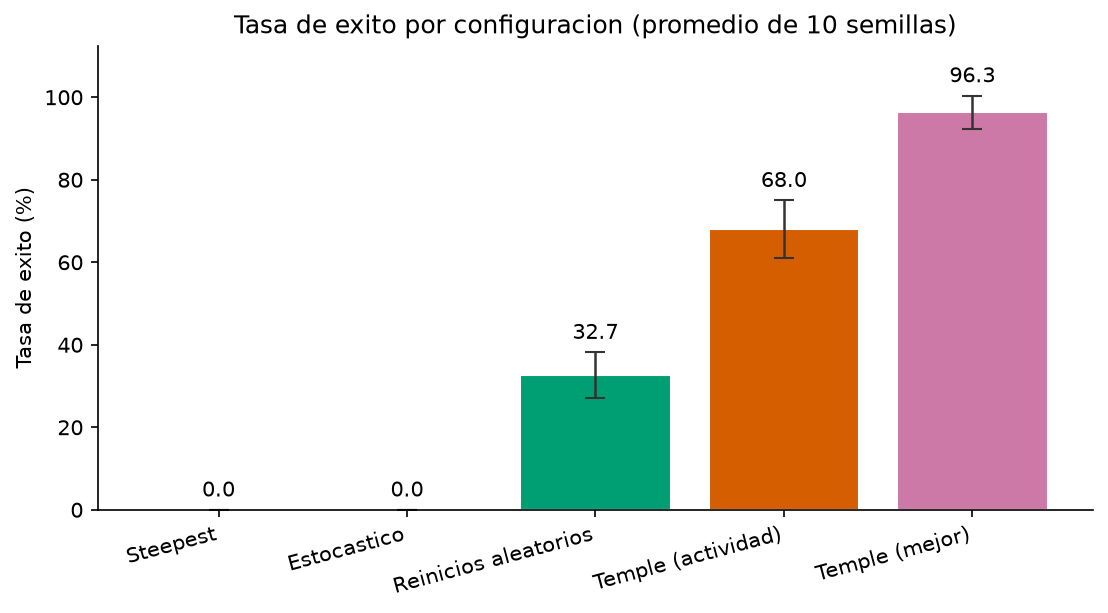

In [9]:
mostrar_figura("ascenso_temple_tasa_exito")

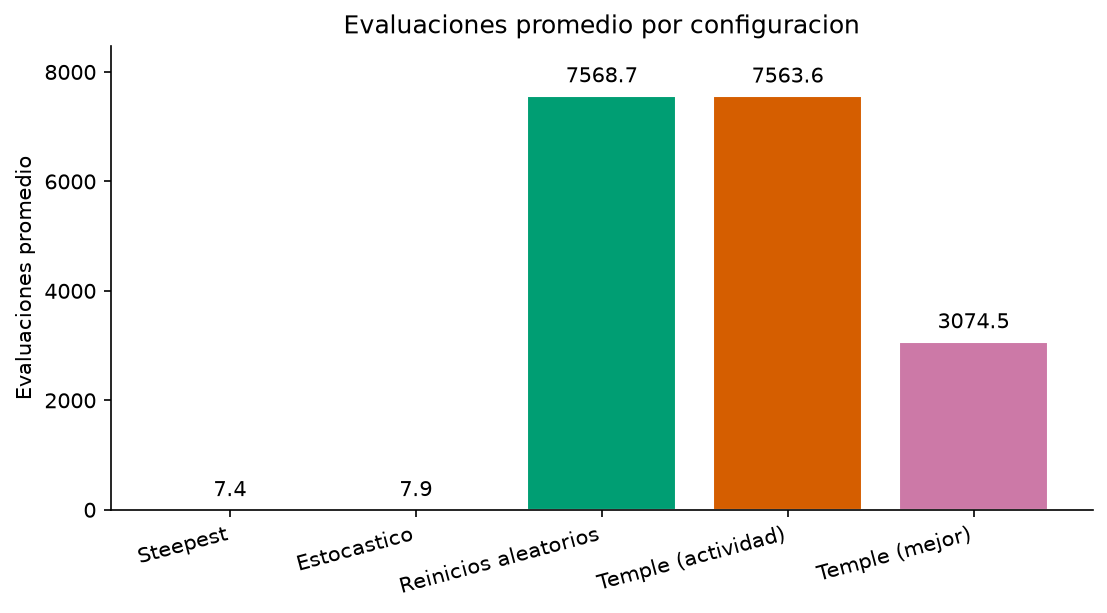

In [10]:
mostrar_figura("ascenso_temple_evaluaciones_promedio")

## 3. Longitud de la solucion

Numero de movimientos de la secuencia que resuelve el tablero (solo
corridas resueltas). En reinicios: movimientos de la caminata del
intento exitoso mas los pasos de steepest. En temple: movimientos
aceptados hasta llegar a h = 0, incluidos los que empeoran o dejan h
igual. Ninguna de las dos se simplifica quitando ciclos.

`razon_sobre_optima_promedio` compara cada solucion con la optima del
mismo tablero, calculada con una busqueda en anchura desde la meta
sobre los 181440 estados resolubles (diametro verificado: 31).

In [11]:
resumen[["configuracion", "corridas_resueltas",
         "longitud_solucion_promedio", "longitud_solucion_desviacion",
         "longitud_solucion_minima", "longitud_solucion_maxima",
         "razon_sobre_optima_promedio"]]

,configuracion,corridas_resueltas,longitud_solucion_promedio,longitud_solucion_desviacion,longitud_solucion_minima,longitud_solucion_maxima,razon_sobre_optima_promedio
0,steepest,0,NaN,NaN,NaN,NaN,NaN
1,estocastico,0,NaN,NaN,NaN,NaN,NaN
2,reinicios,98,31.47,2.73,24.0,40.0,1.60
3,temple_actividad,204,5384.87,1120.80,860.0,6984.0,245.04
4,temple_mejor,289,1473.71,1039.30,51.0,4756.0,66.88


In [12]:
detalle = pd.read_csv(DATOS / "metricas_por_tablero.csv")
print("Longitud optima de los 30 tableros:")
print(detalle.drop_duplicates("tablero_indice")["longitud_optima"]
      .describe()[["mean", "min", "max"]])

Longitud optima de los 30 tableros:
mean    22.5
min     16.0
max     28.0
Name: longitud_optima, dtype: float64


## 4. Casos antes / despues

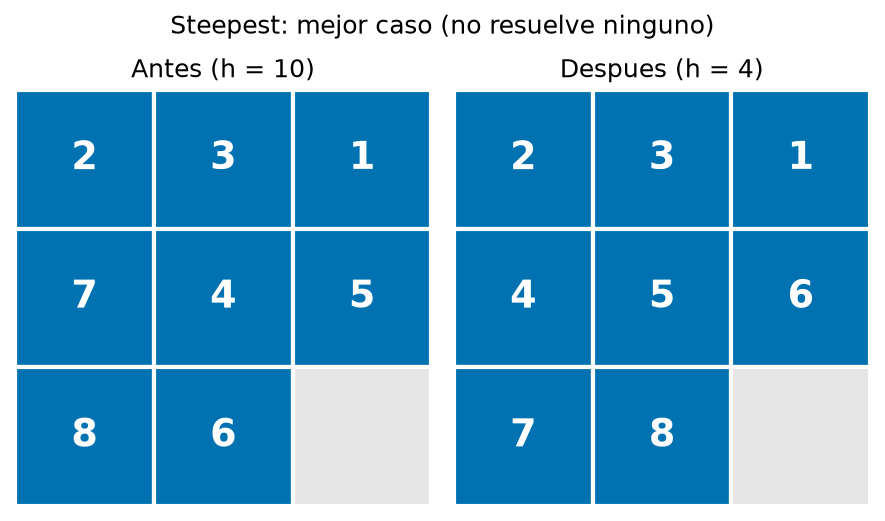

In [13]:
mostrar_figura("antes_despues_steepest")

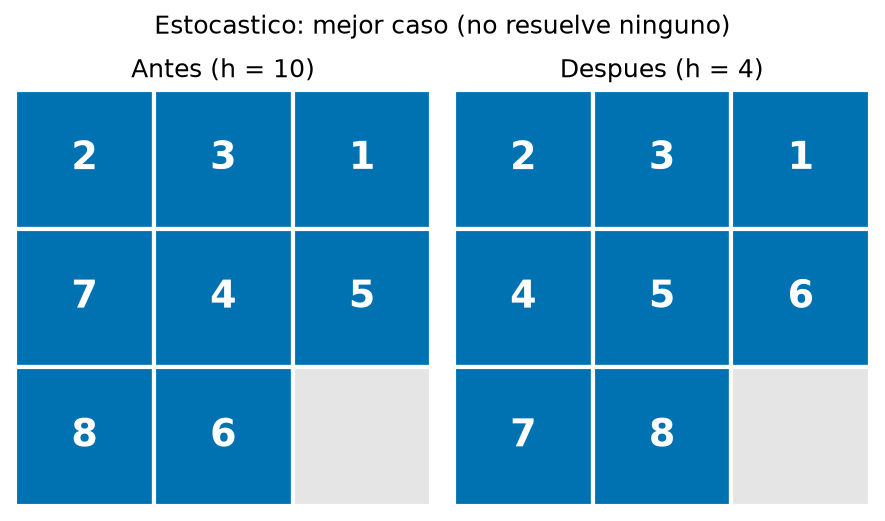

In [14]:
mostrar_figura("antes_despues_estocastico")

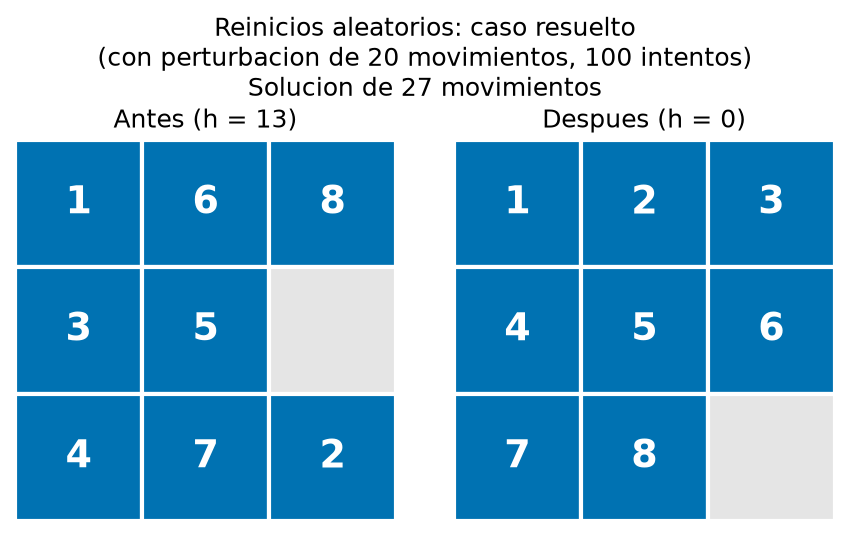

In [15]:
mostrar_figura("antes_despues_reinicios")

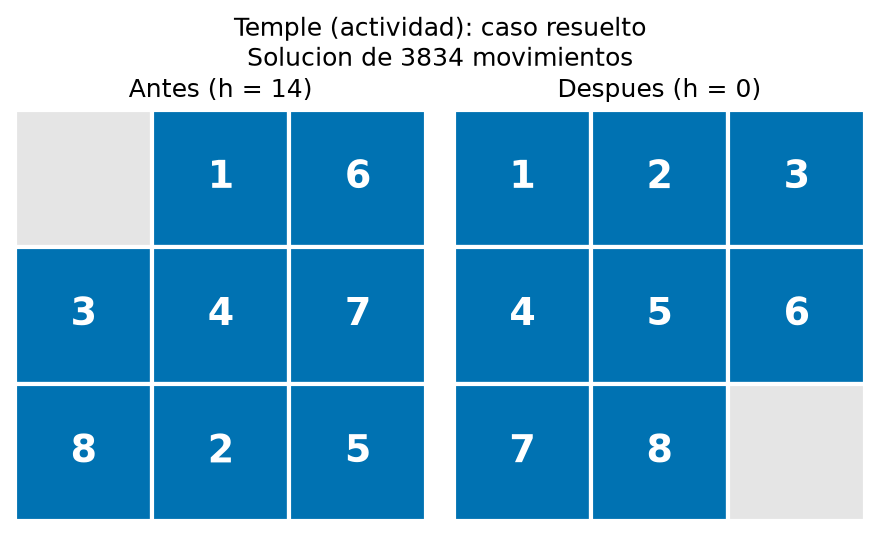

In [16]:
mostrar_figura("antes_despues_temple_actividad")

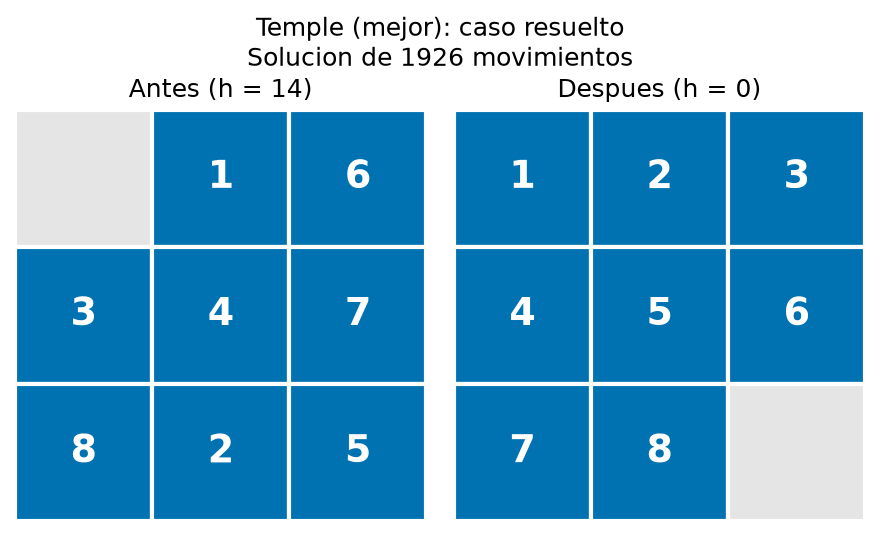

In [17]:
mostrar_figura("antes_despues_temple_mejor")

## 5. Temple simulado: trazas y degradacion

Evolucion de h actual y h mejor (valor al final de cada nivel de
temperatura). Despues, temple con alpha = 0.01 (enfriamiento casi
inmediato) frente a steepest en los 30 tableros: tras el primer nivel
solo acepta mejoras y, como steepest, no resuelve ninguno.

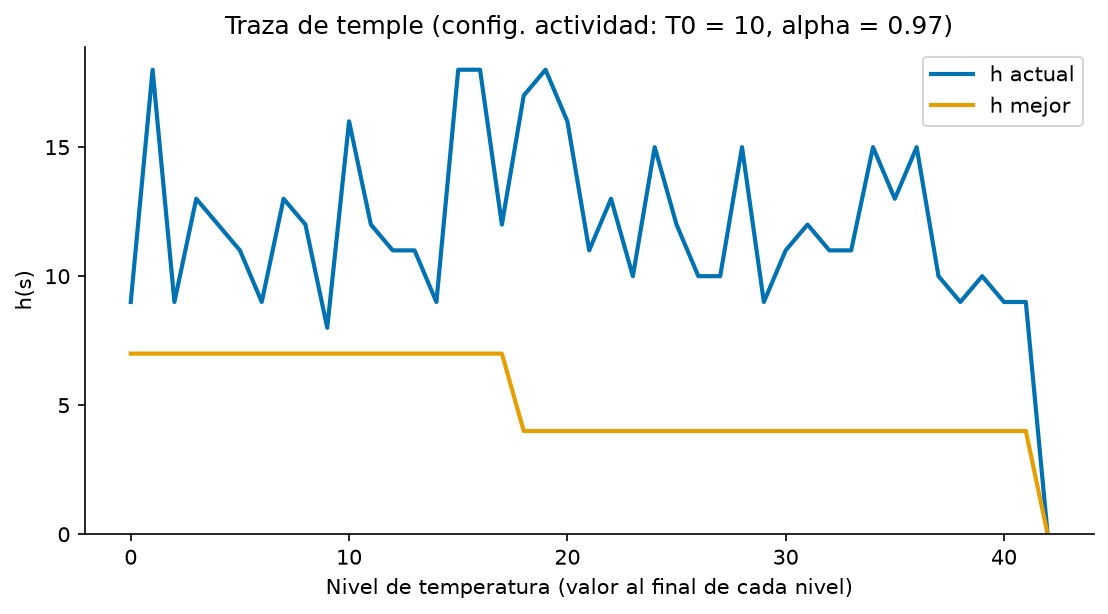

In [18]:
mostrar_figura("temple_actividad_traza")

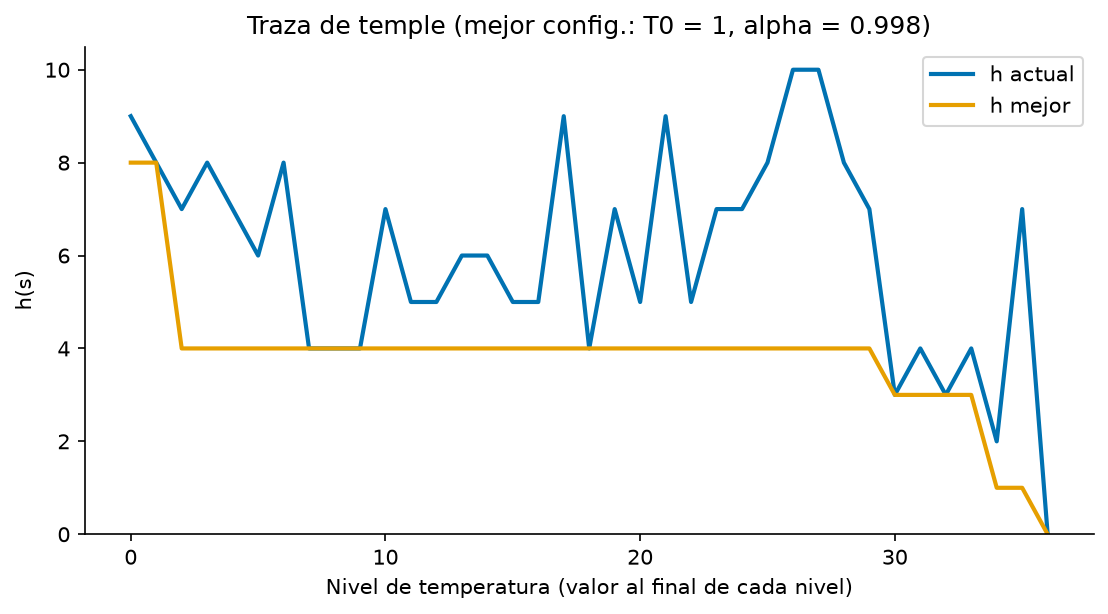

In [19]:
mostrar_figura("temple_mejor_traza")

In [20]:
degradacion = pd.read_csv(DATOS / "temple_alpha_pequeno.csv")
print("Temple alpha = 0.01: resueltos",
      int(degradacion["resuelto"].sum()), "de", len(degradacion),
      "| h final promedio", round(degradacion["h_final"].mean(), 2))

Temple alpha = 0.01: resueltos 0 de 30 | h final promedio 9.57


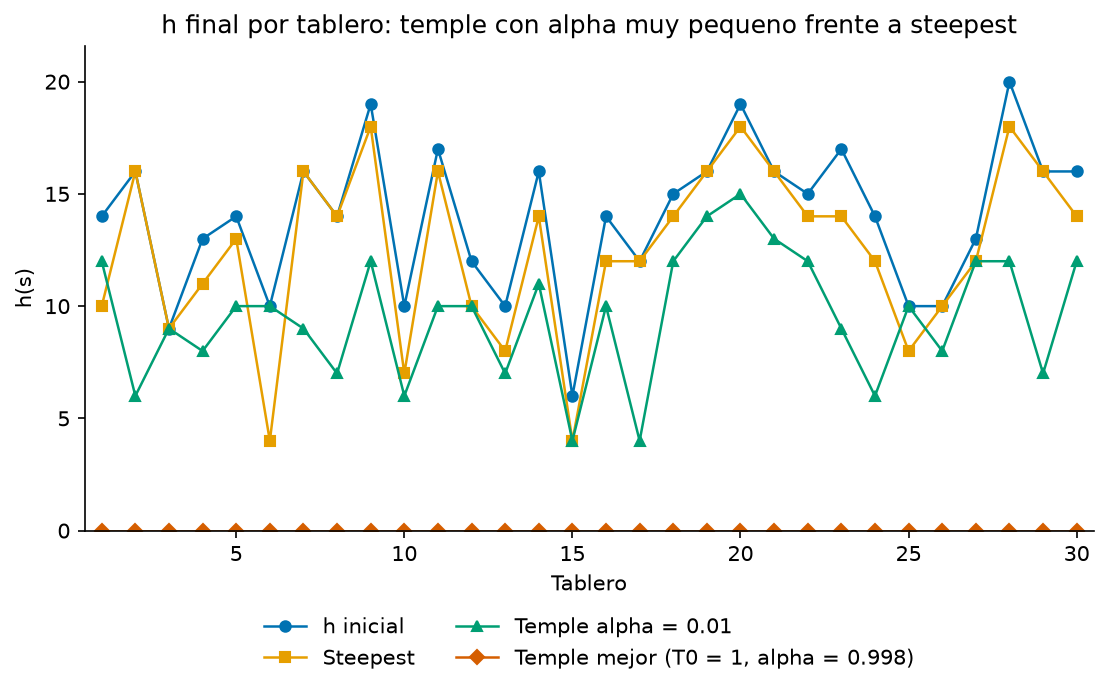

In [21]:
mostrar_figura("temple_alpha_pequeno_vs_ascenso")

## 6. Barrido de T0 y alpha

Todas las combinaciones con el presupuesto compartido. Las que enfrian
mas lento no alcanzan a llegar a T_MINIMO y quedan truncadas
(`porcentaje_truncadas`); se dejan competir asi porque el barrido
responde que configuracion rinde mas con el mismo costo.

In [22]:
barrido = pd.read_csv(DATOS / "temple_barrido.csv")
interaccion = barrido[barrido["tipo"] == "interaccion"]
interaccion.pivot(index="t0", columns="alpha",
                  values="tasa_exito_promedio")

alpha,0.90,0.95,0.97,0.99,0.99,1.00
t0,,,,,,
0.5,2.33,2.00,5.67,11.33,19.33,26.33
1.0,11.67,23.67,38.67,78.33,93.67,96.33
2.0,25.67,44.33,67.67,90.67,87.33,77.33
5.0,25.33,53.00,67.33,44.67,21.67,17.67
10.0,22.67,54.33,68.00,9.00,5.00,4.00
20.0,30.33,50.67,50.00,4.00,3.33,4.33
40.0,30.67,52.00,17.00,2.33,3.67,2.33


In [23]:
interaccion.sort_values(
    ["tasa_exito_promedio", "evaluaciones_promedio"],
    ascending=[False, True]).head(5)[
    ["t0", "alpha", "tasa_exito_promedio", "tasa_exito_desviacion",
     "evaluaciones_promedio", "porcentaje_truncadas"]]

,t0,alpha,tasa_exito_promedio,tasa_exito_desviacion,evaluaciones_promedio,porcentaje_truncadas
26,1.0,1.00,96.33,4.07,3074.50,3.67
25,1.0,0.99,93.67,5.67,3220.08,6.33
30,2.0,0.99,90.67,2.49,4363.01,9.33
31,2.0,0.99,87.33,5.54,4750.53,12.67
24,1.0,0.99,78.33,8.85,3913.15,21.67


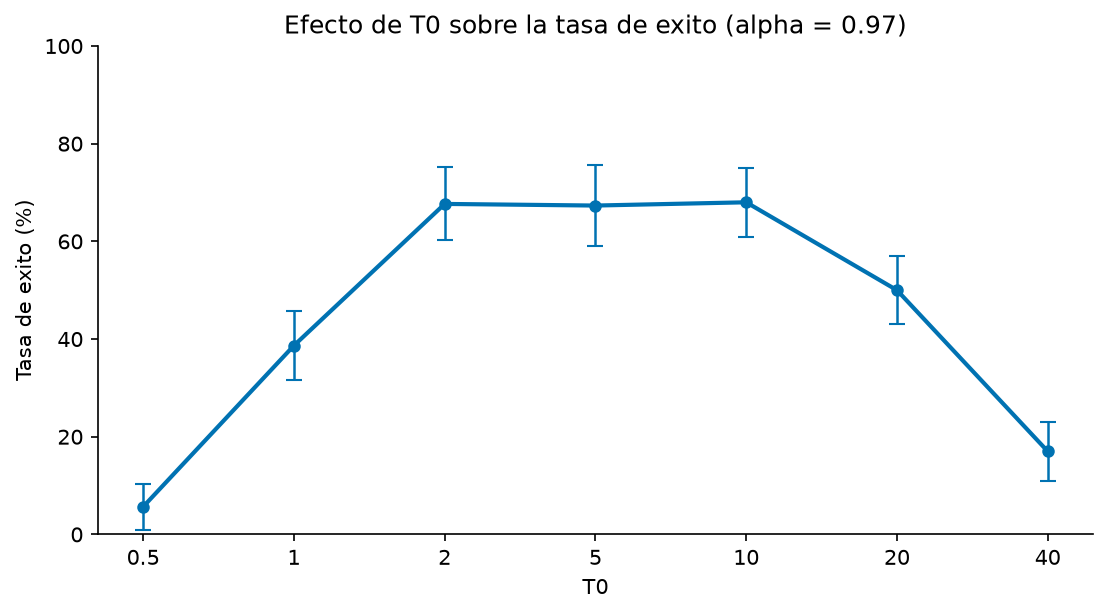

In [24]:
mostrar_figura("temple_efecto_t0")

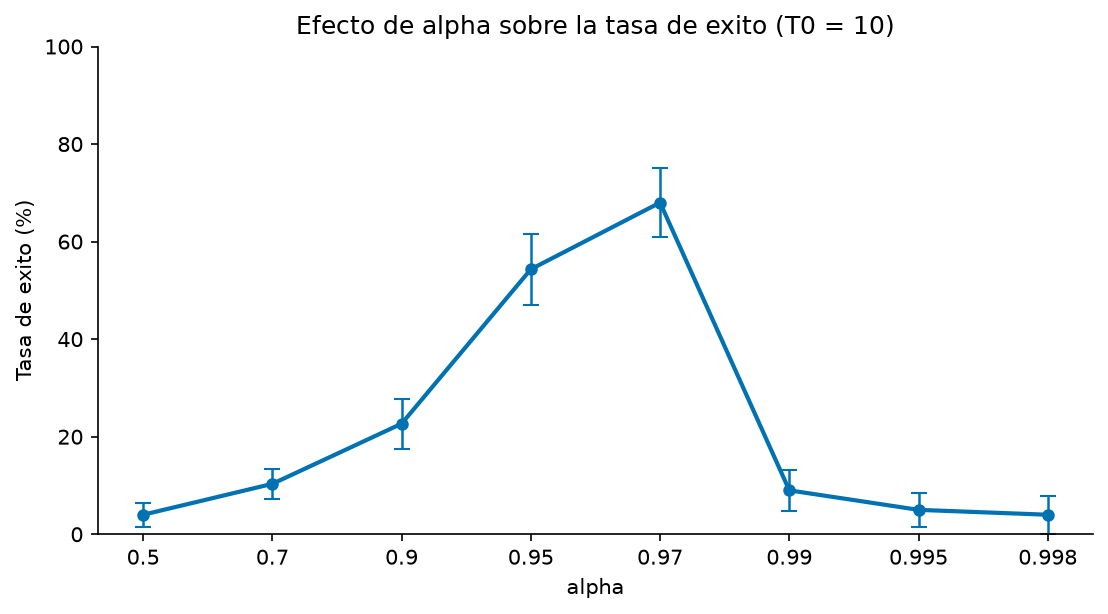

In [25]:
mostrar_figura("temple_efecto_alpha")

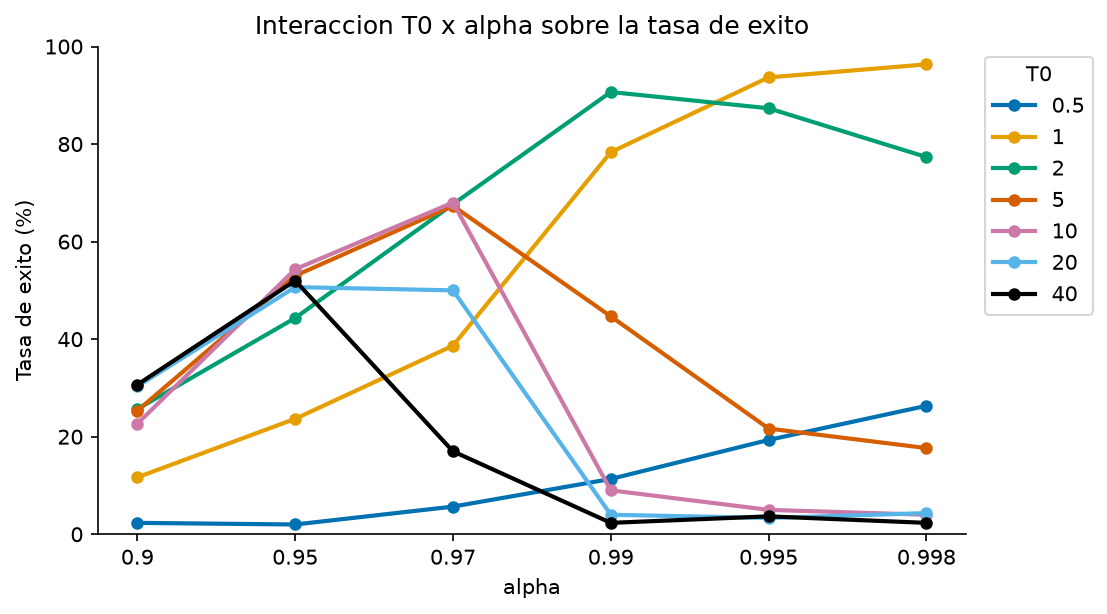

In [26]:
mostrar_figura("temple_interaccion_t0_alpha")

## 7. Barrido de K (analisis aparte)

El barrido de K **no** elige la configuracion de la tabla principal.
Muestra el efecto del largo de la perturbacion: por encima del
diametro (31) la caminata ya puede llegar a cualquier tablero
resoluble y el reinicio se parece a generar un tablero al azar.

In [27]:
barrido_k = pd.read_csv(DATOS / "reinicios_barrido_k.csv")
barrido_k[["k", "principal", "supera_diametro", "tasa_exito_promedio",
           "tasa_exito_desviacion", "evaluaciones_promedio",
           "porcentaje_truncadas", "corridas_resueltas",
           "longitud_solucion_promedio"]]

,k,principal,supera_diametro,tasa_exito_promedio,tasa_exito_desviacion,evaluaciones_promedio,porcentaje_truncadas,corridas_resueltas,longitud_solucion_promedio
0,10,False,False,10.33,1.80,9088.97,89.67,31,21.16
1,20,True,False,32.67,5.54,7568.68,67.33,98,31.47
2,50,False,True,80.33,5.26,4500.61,19.67,241,61.52
3,100,False,True,95.00,3.07,2898.45,5.00,285,110.93
4,200,False,True,97.33,2.49,2545.76,2.67,292,210.94


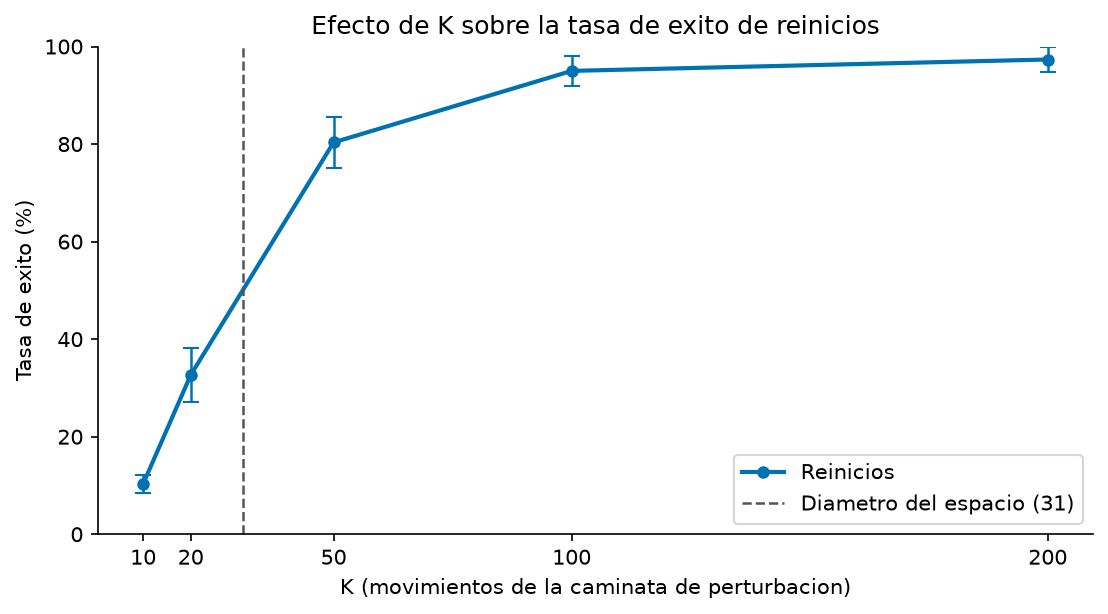

In [28]:
mostrar_figura("reinicios_efecto_k")

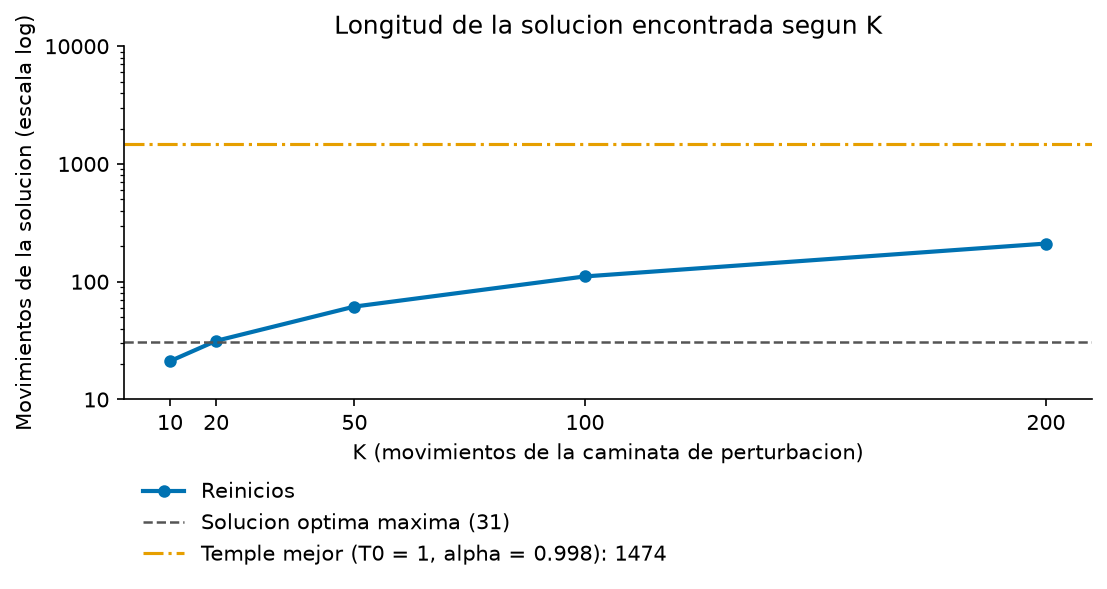

In [29]:
mostrar_figura("reinicios_longitud_vs_k")

## 8. Temple sin tope (contexto)

Temple actividad con las mismas semillas, con y sin presupuesto: la
unica diferencia es el tope de evaluaciones.

In [30]:
sin_tope = pd.read_csv(DATOS / "temple_sin_tope.csv")
sin_tope[["configuracion", "tasa_exito_promedio", "tasa_exito_desviacion",
          "evaluaciones_promedio", "porcentaje_truncadas"]]

,configuracion,tasa_exito_promedio,tasa_exito_desviacion,evaluaciones_promedio,porcentaje_truncadas
0,temple_actividad,68.00,7.02,7563.61,32.0
1,temple_actividad_sin_tope,70.33,6.74,9822.64,0.0


In [31]:
print(sin_tope.loc[1, "nota"])

Sin limite de costo, temple actividad llega a 70.3% gastando 9823 evaluaciones en promedio, MAS que reinicios (K = 20), que gasta 7569 y llega a 32.7%


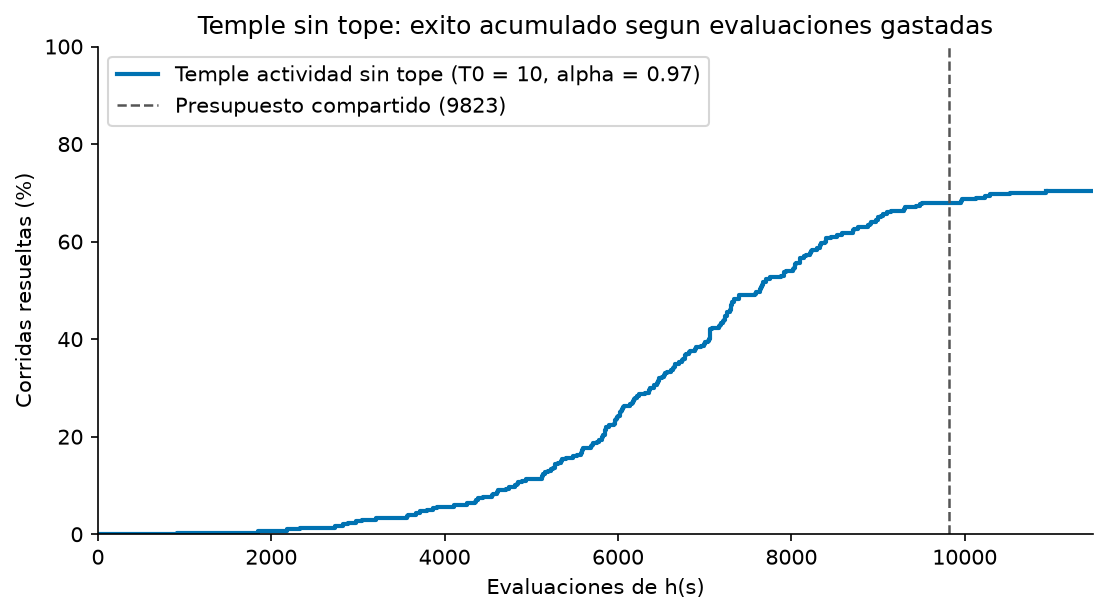

In [32]:
mostrar_figura("temple_sin_tope_exito_acumulado")